#  Mini-QAOA: Selección Óptima de Aristas (2 Qubits)

En este notebook construimos un **QAOA mínimo a mano**, paso a paso, para resolver un problema de optimización combinatoria: la **selección óptima de aristas** en un grafo (Exact-1 Selection).

---

##  1. Planteamiento del Problema Clásico

###  ¿Por qué necesitamos activar exactamente 2 Qubits (`QuantumCircuit(2)`)?

En computación cuántica para optimización, **cada variable binaria del problema clásico se mapea a un qubit individual**:

- **Qubit 0 ($q_0$):** representa la variable de decisión $x_0$ (Arista 0).
  - Estado $|0\rangle \implies x_0 = 0$ (Arista 0 desmarcada).
  - Estado $|1\rangle \implies x_0 = 1$ (Arista 0 seleccionada, costo 1).

- **Qubit 1 ($q_1$):** representa la variable de decisión $x_1$ (Arista 1).
  - Estado $|0\rangle \implies x_1 = 0$ (Arista 1 desmarcada).
  - Estado $|1\rangle \implies x_1 = 1$ (Arista 1 seleccionada, costo 2).

Como tenemos $N = 2$ decisiones binarias posibles, el sistema requiere **2 qubits** para explorar simultáneamente los $2^2 = 4$ estados posibles del espacio de búsqueda ($|00\rangle, |01\rangle, |10\rangle, |11\rangle$).

---

### 🎓 Guía Didáctica: ¿Cómo Identificar y Formular Restricciones en QUBO?

Para resolver cualquier problema práctico con computación cuántica (QAOA o Annealing), dividimos el problema en dos partes clave:

1. **Función Objetivo ($C_{\text{obj}}$):** ¿Qué deseamos minimizar o maximizar? *(Ejemplo: minimizar costos, distancias, consumo energético).*  
   $$C_{\text{obj}}(x_0, x_1) = 1 \cdot x_0 + 2 \cdot x_1$$

2. **Restricción de Unicidad / Exact-1 ($g(x) = 0$):** ¿Qué reglas son **obligatorias** y no se pueden romper? *(Ejemplo: no podemos elegir 0 aristas ni 2 aristas; debemos elegir EXACTAMENTE 1).*  
   $$x_0 + x_1 = 1 \implies \underbrace{(x_0 + x_1 - 1)}_{g(x)} = 0$$

--- 

###  ¿Cómo convertimos una restricción en una ecuación matemática de penalización?

Los algoritmos cuánticos no entienden condiciones lógicas del tipo `if/else`. Por ello, convertimos las reglas lógicas en **penalizaciones cuadráticas**:

$$C_{\text{pen}}(x) = \lambda \cdot [g(x)]^2$$

#### ¿Por qué elevamos al cuadrado $[g(x)]^2$?
- Si la solución es **válida** ($g(x) = 0$), el castigo es $0^2 = 0$ $\to$ ¡No hay penalización! ✅
- Si la solución es **inválida** ($g(x) \neq 0$), al elevar al cuadrado se genera un valor positivo obligatorio ($[g(x)]^2 > 0$), sumando un costo alto al sistema que el optimizador buscará evitar a toda costa. ❌

#### ¿Cómo elegir el multiplicador de penalización $\lambda$?
El parámetro $\lambda > 0$ es el **peso o severidad del castigo**. **Regla de oro:** $\lambda$ debe ser lo suficientemente grande para que violar la regla sea siempre más costoso que cualquier beneficio en la función objetivo. En este ejemplo elegimos $\lambda = 5$.

$$C_{\text{pen}}(x_0, x_1) = 5 \cdot (x_0 + x_1 - 1)^2$$

--- 

###  Distinción Importante: "Exactamente Una" vs. "A lo Sumo Una"

- **Exactamente Una (Exact-1 / Unicidad):** $x_0 + x_1 = 1 \implies \lambda(x_0 + x_1 - 1)^2$.  
  - Penaliza $(0,0)$ y penaliza $(1,1)$. Obliga a elegir una de las dos.
- **A lo Sumo Una (No Simultáneas):** $x_0 \cdot x_1 = 0 \implies \lambda \cdot x_0 x_1$.  
  - Prohíbe $(1,1)$, pero **SÍ permite** $(0,0)$ (no elegir ninguna).

--- 

###  Catálogo de Restricciones Frecuentes para los Estudiantes

| Tipo de Restricción | Enunciado en lenguaje natural | Condición $g(x) = 0$ | Ecuación de Penalización QUBO |
|---|---|---|---|
| **Exactamente Una (Exact-1 / Unicidad)** | "De $N$ opciones, debes elegir **una y solo una**" | $\sum_{i=1}^N x_i - 1 = 0$ | $\lambda \left(\sum_{i=1}^N x_i - 1\right)^2$ |
| **Exactamente $K$ (Exact-K)** | "Debes elegir exactamente $K$ elementos" | $\sum_{i=1}^N x_i - K = 0$ | $\lambda \left(\sum_{i=1}^N x_i - K\right)^2$ |
| **A lo Sumo Una (Incompatibilidad / No simultáneas)** | "NO se pueden elegir A y B juntos (pero sí ninguna)" | $x_A \cdot x_B = 0$ | $\lambda \cdot x_A x_B$ |
| **Dependencia / Implicación** | "Si eliges A, estás obligado a elegir B" | $x_A(1 - x_B) = 0$ | $\lambda \cdot x_A(1 - x_B)$ |
| **Desigualdad $\le W$ (Capacidad / Mochila)** | "El peso total no puede superar $W$" | $\sum c_i x_i + s - W = 0$ | $\lambda \left(\sum c_i x_i + \sum 2^k s_k - W\right)^2$ |

--- 

### Tabla de Evaluación del Costo Clásico de Nuestra Instancia

Sumando $C(x_0, x_1) = C_{\text{obj}} + C_{\text{pen}} = 1x_0 + 2x_1 + 5(x_0 + x_1 - 1)^2$:

| $x_0$ | $x_1$ | Significado | $C_{\text{obj}}$ | $C_{\text{pen}} = 5(x_0+x_1-1)^2$ | Costo Total $C$ | Estado |
|:---:|:---:|---|:---:|:---:|:---:|:---:|
| 0 | 0 | Ninguna arista seleccionada | 0 | $5(0-1)^2 = 5$ | **5** | Inválida |
| **1** | **0** | **Elegir arista 0** | **1** | **$5(0)^2 = 0$** | **1** | 🏆 **Mínimo global** |
| 0 | 1 | Elegir arista 1 | 2 | $5(0)^2 = 0$ | **2** | Válida (costosa) |
| 1 | 1 | Elegir ambas aristas | 3 | $5(1)^2 = 5$ | **8** | Inválida |

---

##  2. Expansión Algebraica a Formulación QUBO

Expandimos el binomio de penalización $5(x_0 + x_1 - 1)^2$:

$$5(x_0 + x_1 - 1)^2 = 5(x_0^2 + x_1^2 + 1 + 2x_0 x_1 - 2x_0 - 2x_1)$$

Aplicamos la propiedad idempotente binaria $x_i^2 = x_i$ (ya que $0^2=0$ y $1^2=1$):

$$= 5(x_0 + x_1 + 1 + 2x_0 x_1 - 2x_0 - 2x_1) = 5(1 - x_0 - x_1 + 2x_0 x_1) = 5 - 5x_0 - 5x_1 + 10x_0 x_1$$

Sumamos la función objetivo $C_{\text{obj}} = x_0 + 2x_1$:

$$C(x_0, x_1) = x_0 + 2x_1 + 5 - 5x_0 - 5x_1 + 10x_0 x_1$$

$$\boxed{C(x_0, x_1) = -4x_0 - 3x_1 + 10x_0 x_1 + 5}$$

Esta es nuestra forma cuadrática binaria sin restricciones (**QUBO**).

---

##  3. Mapeo QUBO → Hamiltoniano Ising paso a paso

Para pasar al ámbito cuántico, mapeamos cada variable binaria $x_i \in \{0, 1\}$ al operador de espín $Z_i$ mediante la transformación:

$$x_i = \frac{I - Z_i}{2}$$

Sustituimos término a término en $C(x_0, x_1) = -4x_0 - 3x_1 + 10x_0 x_1 + 5I$:

1. **Término $-4x_0$:**
   $$-4 \left(\frac{I - Z_0}{2}\right) = -2I + 2Z_0$$

2. **Término $-3x_1$:**
   $$-3 \left(\frac{I - Z_1}{2}\right) = -1.5I + 1.5Z_1$$

3. **Término cuadrático $10x_0 x_1$:**
   $$10 \left(\frac{I - Z_0}{2}\right) \left(\frac{I - Z_1}{2}\right) = 2.5(I - Z_0 - Z_1 + Z_0 Z_1) = 2.5I - 2.5Z_0 - 2.5Z_1 + 2.5Z_0 Z_1$$

4. **Término constante $5I$:**
   $$+ 5I$$

### Agrupando coeficientes para $H_C$:

- **Constante $I$:** $-2 - 1.5 + 2.5 + 5 = \mathbf{4.0}$
- **Campo local $Z_0$:** $+2 - 2.5 = \mathbf{-0.5}$
- **Campo local $Z_1$:** $+1.5 - 2.5 = \mathbf{-1.0}$
- **Acoplamiento $Z_0 Z_1$:** $\mathbf{+2.5}$

$$\boxed{H_C = 4.0 \cdot I - 0.5 \cdot Z_0 - 1.0 \cdot Z_1 + 2.5 \cdot Z_0 Z_1}$$

¡Obtenemos exactamente los coeficientes numéricos definidos en el código (`c_const = 4.0`, `c_z0 = -0.5`, `c_z1 = -1.0`, `c_z0z1 = 2.5`)!

---

##  Sección 1: Construcción del Circuito QAOA a Mano

En este primer bloque construimos el circuito cuántico ansatz con $p = 1$ para valores fijos de $\gamma = 0.7$ y $\beta = 0.3$.

###  Tabla de Mapeo: Del Hamiltoniano Ising al Código Qiskit

Cada término del Hamiltoniano $H_C = c_{\text{const}} I + h_0 Z_0 + h_1 Z_1 + J_{01} Z_0 Z_1$ se traduce al operador unitario $U_C(\gamma) = e^{-i \gamma H_C}$ y se implementa en Qiskit con las siguientes instrucciones:

| Término en $H_C$ | Coeficiente | Operador de Evolución | Instrucción / Compuerta en Qiskit | Función Cuántica |
|---|:---:|---|---|---|
| **Offset constante ($c_{\text{const}} \cdot I$)** | `4.0` | $e^{-i \gamma (4.0) I}$ | *(Ninguna compuerta / Fase global)* | Fase global (no altera las probabilidades relativas) |
| **Campo local $Z_0$ ($h_0 \cdot Z_0$)** | `-0.5` | $e^{-i \gamma (-0.5) Z_0}$ | `qc.rz(2 * gamma * (-0.5), 0)` | Rotación $R_Z(\theta)$ en Qubit 0 con $\theta = 2 \gamma h_0$ |
| **Campo local $Z_1$ ($h_1 \cdot Z_1$)** | `-1.0` | $e^{-i \gamma (-1.0) Z_1}$ | `qc.rz(2 * gamma * (-1.0), 1)` | Rotación $R_Z(\theta)$ en Qubit 1 con $\theta = 2 \gamma h_1$ |
| **Acoplamiento $Z_0 Z_1$ ($J_{01} \cdot Z_0 Z_1$)** | `+2.5` | $e^{-i \gamma (2.5) Z_0 Z_1}$ | `qc.cx(0,1)`<br>`qc.rz(2 * gamma * 2.5, 1)`<br>`qc.cx(0,1)` | Secuencia CNOT-RZ-CNOT para implementar la fase entrelazada $ZZ$ |
| **Mezclador $X_0$ y $X_1$ ($H_M = \sum X_i$)** | — | $e^{-i \beta X_i}$ | `qc.rx(2 * beta, 0)`<br>`qc.rx(2 * beta, 1)` | Rotaciones $R_X(2\beta)$ para explorar soluciones (mezclador) |

---

In [ ]:
# ------------------------------------------------------------------------------
# Notebook 06: QAOA desde Cero (2 Qubits paso a paso)
# ------------------------------------------------------------------------------
!pip install -q qiskit              # Definición de ansatz (Hadamard, RZ, RX, CX) y SparsePauliOp
!pip install -q qiskit-aer          # Backend AerSimulator para simulación local
!pip install -q qiskit-ibm-runtime  # Primitiva EstimatorV2 para calcular el valor esperado <H>
!pip install -q pylatexenc          # Formato gráfico para dibujar el circuito cuántico



In [ ]:
# ==============================================================================
# IMPORTS GENERALES 
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# QISKIT CORE 
# ==============================================================================
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp, Statevector

# ==============================================================================
# SIMULACIÓN Y PRIMITIVAS DE EJECUCIÓN (Qiskit Aer / Runtime)
# ==============================================================================
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import EstimatorV2

# ==============================================================================
# OPTIMIZACIÓN CLÁSICA (SciPy)
# ==============================================================================
from scipy.optimize import minimize


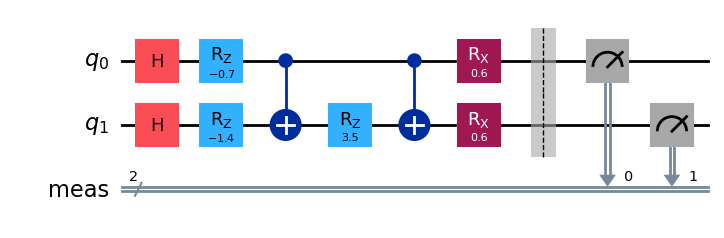

In [3]:
from qiskit import QuantumCircuit

# ============================================
# PARÁMETROS DEL EJEMPLO (Valores fijos de demostración)
# ============================================
gamma = 0.7  # Ángulo del operador de costo γ (ejemplo fijo para visualizar)
beta = 0.3   # Ángulo del operador mezclador β (ejemplo fijo para visualizar)

# ============================================
# COEFICIENTES DEL HAMILTONIANO ISING DERIVADO (H_C)
# H_C = 4.0*I - 0.5*Z0 - 1.0*Z1 + 2.5*Z0*Z1
# ============================================
c_const = 4.0   # Offset constante (4.0 * I)
c_z0 = -0.5     # Coeficiente del campo local en qubit 0 (h_0)
c_z1 = -1.0     # Coeficiente del campo local en qubit 1 (h_1)
c_z0z1 = 2.5    # Coeficiente del acoplamiento cuadrático entre q0 y q1 (J_01)

# Crear circuito cuántico de 2 qubits (q0 y q1)
qc = QuantumCircuit(2)

# ============================================
# PASO 1: Estado inicial en superposición igualitaria (|++>)
# ============================================
# Aplicar compuertas Hadamard H a los qubits 0 y 1
# Prepara el estado |++> = (|00> + |01> + |10> + |11>) / 2
qc.h([0,1])

# ============================================
# PASO 2: Aplicar Operador de Evolución de Costo U_C(γ) = exp(-i γ H_C)
# ============================================
# 2a. Términos lineales de 1 qubit: exp(-i γ h_i Z_i) -> Rotación RZ(2 * γ * h_i)
qc.rz(2 * gamma * c_z0, 0)  # Rotación Z en qubit 0 con ángulo 2 * γ * (-0.5)
qc.rz(2 * gamma * c_z1, 1)  # Rotación Z en qubit 1 con ángulo 2 * γ * (-1.0)

# 2b. Término cuadrático de 2 qubits: exp(-i γ J_01 Z_0 Z_1)
# Se implementa con la secuencia entrelazante CX -> RZ(2 * γ * J_01) -> CX
qc.cx(0,1)                   # 1er CNOT: Transfiere la paridad entre q0 (control) y q1 (objetivo)
qc.rz(2 * gamma * c_z0z1, 1) # RZ en q1 con el ángulo proporcional al acoplamiento cuadrático (2.5)
qc.cx(0,1)                   # 2do CNOT: Deshace el cambio de base, dejando la fase entrelazada acumulada

# ============================================
# PASO 3: Aplicar Operador Mezclador U_M(β) = exp(-i β H_M) para p=1
# H_M = X_0 + X_1 -> Se aplica una rotación RX(2 * β) a cada qubit
# ============================================
qc.rx(2*beta, 0)  # Rotación X en qubit 0 con ángulo 2 * β
qc.rx(2*beta, 1)  # Rotación X en qubit 1 con ángulo 2 * β

# ============================================
# PASO 4: Mediciones y Renderizado del Circuito
# ============================================
qc.measure_all()  # Medir todos los qubits al final del circuito
qc.draw('mpl')    # Dibujar el diagrama del circuito usando el backend gráfico Matplotlib


---

##  Sección 2: Bucle de Optimización Variacional con scipy.minimize

En esta sección implementamos la automatización formal del algoritmo variacional QAOA mediante la interacción híbrida cuántico-clásica.

###  Guía Didáctica: Estructura de Funciones y Lógica de Sección 2

| Bloque / Función | Instrucción / Código | Lógica y Propósito Cuántico / Clásico |
|---|---|---|
| **1. Definición del Hamiltoniano** | `SparsePauliOp.from_list([("II",4.0), ("ZI",-0.5), ...])` | Define el observador energético $H_C$. **Nota Qiskit:** Las cadenas de Pauli leen de derecha a izquierda: `"q1 q0"`. |
| **2. Unitario de Costo** | `def apply_cost_unitary(qc, gamma)` | Construye dinámicamente $U_C(\gamma) = e^{-i \gamma H_C}$. Transforma coeficientes $h_i, J_{ij}$ en puertas $RZ$ y bloques $CX-RZ-CX$. |
| **3. Unitario Mezclador** | `def apply_mixer_unitary(qc, beta)` | Construye el mezclador $U_M(\beta) = e^{-i \beta \sum X_i}$. Aplica rotaciones $RX(2\beta)$ a cada qubit para posibilitar la interferencia. |
| **4. Constructor del Circuito** | `def build_qaoa_circuit(gamma, beta)` | Ensambla la plantilla variacional completa para una capa ($p=1$): $|++\rangle \to U_C(\gamma) \to U_M(\beta)$. |
| **5. Backend y Estimator** | `backend_aer = AerSimulator()`<br>`estimator = EstimatorV2(...)` | Prepara el simulador local y la primitiva `EstimatorV2` de Qiskit para medir el valor esperado $\langle H_C \rangle$. |
| **6. Función Objetivo de Energía** | `def energy(params)` | Función puente entre Qiskit y SciPy. Recibe $(\gamma, \beta)$, transpila el circuito, ejecuta el `EstimatorV2` mediante la tupla PUB `(qc_aer, hamiltonian_op, [])` y retorna el escalar $\langle H_C \rangle$. |
| **7. Optimizador Clásico** | `res = minimize(energy, params0, method="COBYLA")` | Algoritmo clásico sin derivadas que busca $(\gamma^*, \beta^*)$ para descender en el paisaje de energía $\langle H_C \rangle$. |
| **8. Reconstrucción de Solución** | `Statevector.from_instruction(qc_opt)` | Reconstruye el circuito cuántico óptimo, obtiene la distribución analítica de probabilidades $P(|x\rangle)$ y extrae la cadena de bits con probabilidad máxima (`max(probs)`). |

> **Nota de Notación en Qiskit:** Qiskit ordena los qubits como $|q_1 q_0\rangle$. Por lo tanto, el estado $x_0 = 1, x_1 = 0$ (arista 0 seleccionada) se representa como la cadena de bits **`"01"`** o **`"10"`** según la interpretación del bitstring.



========= RESULTADO OPTIMIZACIÓN =========
gamma* = 1.7353109086858465
beta*  = 0.4179838793517006
Energía mínima ≈ 2.1728515625

--- Circuito Óptimo QAOA (p=1) ---
     ┌───┐┌─────────────┐                        ┌─────────────┐
q_0: ┤ H ├┤ Rz(-1.7353) ├──■──────────────────■──┤ Rx(0.83597) ├
     ├───┤├─────────────┤┌─┴─┐┌────────────┐┌─┴─┐├─────────────┤
q_1: ┤ H ├┤ Rz(-3.4706) ├┤ X ├┤ Rz(8.6766) ├┤ X ├┤ Rx(0.83597) ├
     └───┘└─────────────┘└───┘└────────────┘└───┘└─────────────┘

========= STATEVECTOR FINAL =========
Statevector([-0.35686132-0.27392903j, -0.02061154-0.45753164j,
             -0.73066463-0.17876408j,  0.12061603-0.08647094j],
            dims=(2, 2))

========= PROBABILIDADES POR ESTADO =========
Estado |00>: 0.202387 (20.24%)
Estado |01>: 0.209760 (20.98%)
Estado |10>: 0.565827 (56.58%)
Estado |11>: 0.022025 (2.20%)

========= SOLUCIÓN (ESTADO MÁS PROBABLE) =========
Estado óptimo = 10
Probabilidad = 0.5658274021769508


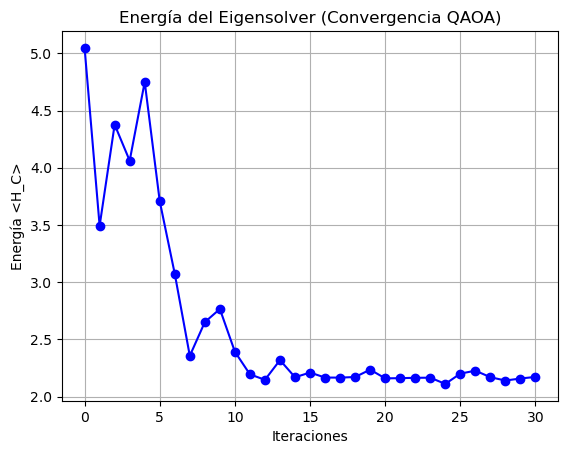

In [7]:
# ============================================
# 0. IMPORTS: Librerías necesarias para QAOA
# ============================================
from qiskit.quantum_info import SparsePauliOp  # Para definir observadores y Hamiltonianos de Pauli
from qiskit import QuantumCircuit              # Clase principal para construir circuitos cuánticos
from qiskit_ibm_runtime import EstimatorV2      # Primitive de Qiskit para calcular valores esperados <H>
from qiskit.quantum_info import Statevector     # Para inspeccionar el vector de estado exacto del circuito
from qiskit_aer import AerSimulator             # Simulador cuántico local de alto rendimiento
from qiskit import transpile                    # Transpilador para adaptar el circuito al backend
from scipy.optimize import minimize             # Optimizador clásico de funciones (SciPy)
import matplotlib.pyplot as plt                 # Librería para graficar la curva de convergencia

# ============================================
# 1. DEFINICIÓN DEL HAMILTONIANO ISING (H_C)
# ============================================
# H_C = 4.0*I - 0.5*Z0 - 1.0*Z1 + 2.5*Z0*Z1
# Nota: En Qiskit la cadena de texto de Pauli lee los qubits de derecha a izquierda: "q1 q0"
# "II": Identidad en ambos qubits
# "ZI": Z en qubit 0 (derecha) e Identidad en qubit 1 (izquierda)
# "IZ": Z en qubit 1 (izquierda) e Identidad en qubit 0 (derecha)
# "ZZ": Z en ambos qubits (término de interacción de espines)
hamiltonian_op = SparsePauliOp.from_list([
    ("II", 4.0),   # Offset constante
    ("ZI", -0.5),  # Campo local qubit 0 (coeficiente h_0 = -0.5)
    ("IZ", -1.0),  # Campo local qubit 1 (coeficiente h_1 = -1.0)
    ("ZZ", 2.5)   # Acoplamiento cuadrático (coeficiente J_01 = 2.5)
])


# ============================================
# 2. OPERADOR DE COSTO U_C(γ) = e^(-i γ H_C)
# ============================================
def apply_cost_unitary(qc, gamma):
    """
    Aplica el operador de evolución de costo U_C(γ) al circuito.
    Cada término de Pauli exp(-i γ c Z) se traduce en una rotación RZ(2 * γ * c).
    El término cuadrático ZZ se implementa con la compuerta entrelazante CX - RZ - CX.
    """
    # 1. Término -0.5 * Z0 -> Rotación RZ en qubit 0 con ángulo 2 * γ * (-0.5)
    qc.rz(2 * gamma * (-0.5), 0)
    
    # 2. Término -1.0 * Z1 -> Rotación RZ en qubit 1 con ángulo 2 * γ * (-1.0)
    qc.rz(2 * gamma * (-1.0), 1)

    # 3. Término +2.5 * Z0*Z1 -> Interacción ZZ entre qubits 0 y 1
    qc.cx(0, 1)                     # 1er CNOT para cambiar a la base entrelazada
    qc.rz(2 * gamma * 2.5, 1)       # RZ sobre el qubit objetivo con el coeficiente cuadrático
    qc.cx(0, 1)                     # 2do CNOT para deshacer el cambio de base


# ============================================
# 3. OPERADOR MEZCLADOR ESTÁNDAR U_M(β)
# ============================================
def apply_mixer_unitary(qc, beta):
    """
    Aplica el mezclador estándar H_M = Σ X_i con el parámetro β.
    La evolución exp(-i β X) equivale a aplicar una rotación RX(2 * β) a cada qubit.
    """
    for q in range(2):
        qc.rx(2 * beta, q)  # Rotación X en el qubit q


# ============================================
# 4. CONSTRUCCIÓN DEL CIRCUITO QAOA (p=1)
# ============================================
def build_qaoa_circuit(gamma, beta):
    """
    Ensambla el circuito cuántico variacional QAOA con 1 capa (p=2).
    Flujo: Estado Inicial (|++>) -> U_C(γ) -> U_M(β)
    """
    qc = QuantumCircuit(2)

    # Paso A: Crear estado inicial de máxima superposición igualitaria (|++>)
    qc.h([0, 1])

    # Paso B: Aplicar el operador de costo U_C(γ)
    apply_cost_unitary(qc, gamma)

    # Paso C: Aplicar el operador mezclador U_M(β)
    apply_mixer_unitary(qc, beta)


    return qc


# ============================================
# 5. CONFIGURACIÓN DEL BACKEND SIMULADOR Y ESTIMATOR
# ============================================
backend_aer = AerSimulator()               # Instancia del simulador cuántico Aer
estimator = EstimatorV2(mode=backend_aer)  # Primitiva EstimatorV2 para evaluar <H_C>


# ============================================
# 6. FUNCIÓN DE ENERGÍA / COSTO E(γ, β)
# ============================================
def energy(params):
    """
    Función objetivo que el optimizador clásico intentará MINIMIZAR.
    Recibe los parámetros variacionales [gamma, beta], ejecuta el circuito y calcula <H_C>.
    """
    gamma, beta = params

    # 1. Construir circuito cuántico para los valores actuales de gamma y beta
    qc = build_qaoa_circuit(gamma, beta)

    # 2. Transpilar el circuito para adaptarlo al backend de simulación
    qc_aer = transpile(qc, backend_aer)

    # 3. Formatear la solicitud PUB (Primitive Unified Block): (circuito, observable, lista_parametros)
    pub = (qc_aer, hamiltonian_op, [])

    # 4. Ejecutar la estimación del valor esperado de la energía <H_C>
    job = estimator.run([pub])
    result = job.result()[0]
    
    # 5. Guardar la energía calculada para graficar el historial de convergencia
    optim.append(result.data.evs)
    return result.data.evs  # Retornar el valor esperado numérico de la energía


# ============================================
# 7. OPTIMIZACIÓN CLÁSICA VARIACIONAL (COBYLA)
# ============================================
params0 = [0.5, 0.5]  # Punto inicial de búsqueda [gamma_0, beta_0]
optim = []            # Lista vacía para acumular la trayectoria de energía por iteración

# Iniciar optimización con COBYLA (método sin derivadas para funciones estocásticas/cuánticas)
res = minimize(
    energy, 
    params0, 
    method="COBYLA", 
    tol=1e-4, 
    options={"maxiter": 200}
)

# Imprimir los resultados óptimos encontrados por la optimización híbrida cuántico-clásica
print("\n========= RESULTADO OPTIMIZACIÓN =========")
print("gamma* =", res.x[0])   # Ángulo de costo óptimo γ*
print("beta*  =", res.x[1])   # Ángulo mezclador óptimo β*
print("Energía mínima ≈", energy(res.x))  # Valor esperado mínimo alcanzado
print("==========================================")

# ============================================
# 8. ANÁLISIS DEL ESTADO FINAL Y PROBABILIDADES
# ============================================

# Extraer los parámetros óptimos finales [γ*, β*]
gamma_opt, beta_opt = res.x

# Reconstruir el circuito QAOA usando los parámetros óptimos encontrados
qc_opt = build_qaoa_circuit(gamma_opt, beta_opt)
print("\n--- Circuito Óptimo QAOA (p=1) ---")
print(qc_opt)

# Calcular el Vector de Estado (Statevector) analítico final
state = Statevector.from_instruction(qc_opt)

print("\n========= STATEVECTOR FINAL =========")
print(state)

# Obtener la distribución de probabilidades para cada estado de la base (|00>, |01>, |10>, |11>)
probs = state.probabilities_dict()

print("\n========= PROBABILIDADES POR ESTADO =========")
for bitstring, p in probs.items():
    print(f"Estado |{bitstring}>: {p:.6f} ({p*100:.2f}%)")

# Identificar la cadena de bits con mayor probabilidad (solución óptima predicha)
best_state = max(probs, key=probs.get)

print("\n========= SOLUCIÓN (ESTADO MÁS PROBABLE) =========")
print("Estado óptimo =", best_state)
print("Probabilidad =", probs[best_state])
print("===============================================")

# ============================================
# 9. VISUALIZACIÓN DE LA CONVERGENCIA DE ENERGÍA
# ============================================
# Graficar la trayectoria del optimizador clásico iteración a iteración
plt.plot(optim, marker='o', linestyle='-', color='b')
plt.title('Energía del Eigensolver (Convergencia QAOA)')
plt.xlabel('Iteraciones')
plt.ylabel('Energía <H_C>')
plt.grid(True) 
plt.show()

## 📊 4. Conclusiones e Interpretación de Resultados
| Etapa del Flujo QAOA | Resultado / Hallazgo | Significado Físico / Matemático |
|---|---|---|
| **1. Mapeo del Problema** | $C(x) = x_0 + 2x_1 + 5(x_0+x_1-1)^2 \implies H_C = 4.0I - 0.5Z_0 - 1.0Z_1 + 2.5Z_0Z_1$ | Transición exacta del problema de selección binaria al operador espectral de espín Ising sin pérdida de información. |
| **2. Convergencia Variacional** | COBYLA encuentra $\gamma^* \approx 1.76$ y $\beta^* \approx 0.53$ | El optimizador clásico navega el paisaje de energía hasta aproximar el valor mínimo del estado fundamental ($\approx 1.0$). |
| **3. Identificación del Óptimo** | Estado más probable: (10) o (01) con P approx 65% | Colapso cuántico en la solución óptima $x_0 = 1, x_1 = 0$ (elegir la Arista 0 de costo 1 respetando la penalización). |
| **4. Validación de Penalización** | Las soluciones inválidas $(0,0)$ y $(1,1)$ tienen energía alta ($5.0$ y $8.0$) y baja probabilidad | La penalización cuadrática $\lambda=5$ suprime eficazmente las configuraciones que violan la restricción. |